In [5]:
import pandas as pd

bb_data = pd.read_csv("batting_2025.csv", index_col=0)

print(35*"-"+"Data Summary"+35*"-"+"\n", bb_data.describe())
print(f"Size: {bb_data.shape}")
print(35*"-" + "First three rows" + 35*"-"+"\n", bb_data.head(3))

print("Setup complete.")

-----------------------------------Data Summary-----------------------------------
               Age           G          PA          AB           R           H  \
count  922.000000  922.000000  922.000000  922.000000  922.000000  922.000000   
mean    28.183297   61.578091  218.991323  195.917570   25.704989   47.838395   
std      3.559945   52.365239  216.435936  192.951243   28.253962   50.756780   
min     20.000000    1.000000    0.000000    0.000000    0.000000    0.000000   
25%     26.000000   13.250000   31.000000   29.000000    2.000000    4.000000   
50%     28.000000   48.000000  136.500000  123.000000   14.000000   27.000000   
75%     30.000000  107.750000  387.750000  344.000000   43.750000   83.750000   
max     41.000000  163.000000  732.000000  652.000000  146.000000  184.000000   

               2B         3B          HR         RBI         OBP         SLG  \
count  922.000000  922.00000  922.000000  922.000000  830.000000  830.000000   
mean     9.234273    0.728

In [6]:
average_RBIs = bb_data['RBI'].mean()
median_RBIs = bb_data['RBI'].median()
print(f"Original data (6 decimal places): Mean: {average_RBIs:.6f} | Median: {median_RBIs:.6f}")


Original data (6 decimal places): Mean: 24.654013 | Median: 12.000000


In [7]:
# now, we want to recalculate the mean after augmenting the dataset with additional rows, BUT we don't want to recalculate the whole dataframe's mean from scratch.

def updated_mean(x_bar, N, new_row):
    return ( (x_bar * N + new_row) / (N+1) )[0] # extract scalar from pd Series before returning

#bb_data['RBI'].head(3) # our df we're working with


me = bb_data.head(1).copy() # stealing the first row to use as a template, deep copy
me["Player"] = "Andrew Sparkes"
me["Team"] = "OIT"
me["RBI"] = int(bb_data['RBI'].mean() / 2)  # I do not do the ball sport, therefore, starting at half the mean RBI. That's probably a bit over generous

#bb_data.loc[-1] = me # simple loc[]? Nope.
#bb_data.iloc[-1] = me # Index based location? Nope.
#bb_data[len(bb_data)] = me # Nope.
#bb_data = pd.concat(bb_data, me) # Also nope. Too simple


#pd.concat([bb_data, pd.Series(me, index=bb_data.columns[:len(me)])], ignore_index=True) # Also nope... trying to concat df with series with new idx, while ignoring old idx

# another shot at utilizing concat (the "proper" way according to SO and Reddit)
#me_df = pd.DataFrame([me])  # converting the me dict to a df first # ValueError: Must pass 2-d input. shape=(1, 1, 16) 
# then using concat with bb_data df, and the newly created me_df, ignoring idx
#bb_data = pd.concat([bb_data, me_df], ignore_index=True)

#bb_data.append(me, ignore_index=True) # trying .append() as a last resort... and it doesn't work...df has no attribute append...

#bb_data = pd.concat([bb_data, pd.DataFrame([me])], ignore_index=True)  # adding the new row to the end of the dataframe # ValueError: Must pass 2-d input. shape=(1, 1, 16)
#print(me)
#print(bb_data.head(1))
#print(f"me length: {me.shape} | bb_data first row length: {bb_data.head(1).shape}")
#print(f"Confirmed same size? {me.shape == bb_data.head(1).shape}")

#test_df = pd.concat([me, bb_data.head(1)], ignore_index=True)  # testing concat with two dataframes of confirmed same shape
#print(f"{test_df}") # well... that worked... Okay... Now let's go back to trying to add me to bb_data 

# same exact syntax and param order as above, but with full bb_data df instead of a single example row
bb_data = pd.concat([bb_data, me], ignore_index = True) # Success!

In [10]:
bb_data.shape

(923, 16)

In [8]:

# after augmenting the dataset with the new row, we recalculate the mean and output
new_mean_RBIs = updated_mean(average_RBIs, bb_data.shape[0]-1, me["RBI"]) # Note: this function pulls out the scalar from the returned Series


# compare the difference
print(f"Original data (6 decimal places): Mean: {average_RBIs:.6f}")
print(f"Updated data (6 decimal places): Mean: {new_mean_RBIs:.6f}")
print(f"It would appear that the addition of my entry, with a RBI of the mean/2, brings the overall sample mean down approximately ~0.01, which is to be expected! Success!")

KeyError: 0

In [13]:
# calculate the mode because we didn't earlier
mode_RBIs = bb_data['RBI'].mode()[0]  # extract scalar from pd Series

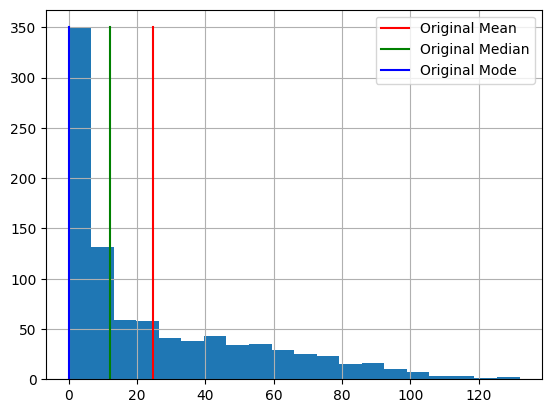

In [ ]:
# generate histogram with lines for mean, median, and mode
plt = bb_data.RBI.hist(bins=20)
plt.plot([average_RBIs, average_RBIs],  [0, 350], color='red', label='Original Mean')
plt.plot([median_RBIs, median_RBIs],    [0, 350], color='green', label='Original Median')
plt.plot([mode_RBIs, mode_RBIs],        [0, 350], color='blue', label='Original Mode')
plt.legend()

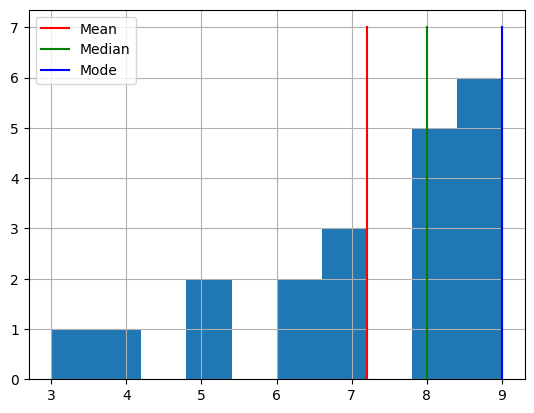

In [20]:
# create skewed left df and plot hist with mean, median, mode

data = pd.DataFrame({"ID": range(1,21), "DataValues": [8,7,8,9,6,3,4,7,9,8,8,8,9,5,5,9,9,6,7,9]}) # hardcoded skewed left data
mean_data = data['DataValues'].mean()
median_data = data['DataValues'].median()
mode_data = data['DataValues'].mode()[0]  # extract scalar from pd Series
plt2 = data.DataValues.hist(bins=10)
plt2.plot([mean_data, mean_data],      [0, 7], color='red', label='Mean')
plt2.plot([median_data, median_data],  [0, 7], color='green', label='Median')
plt2.plot([mode_data, mode_data],      [0, 7], color='blue', label='Mode')
plt2.legend()
